#### Chart: Visualizing Singular Value Decompositions


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week12/chart_visualizing_singular_value_decompositions.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week12/chart_visualizing_singular_value_decompositions.ipynb)



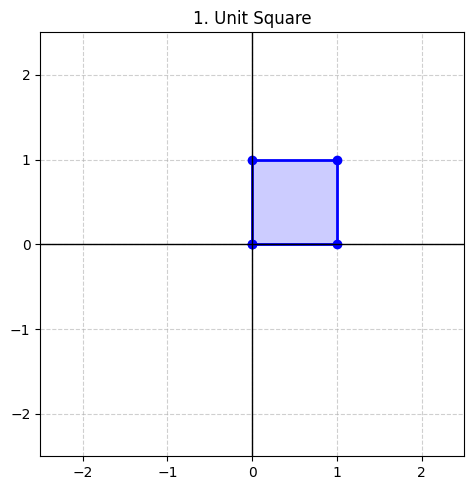

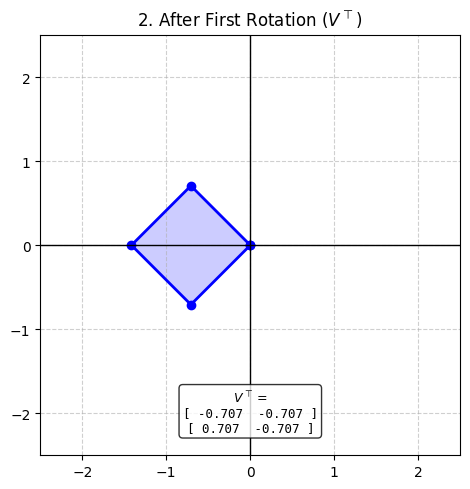

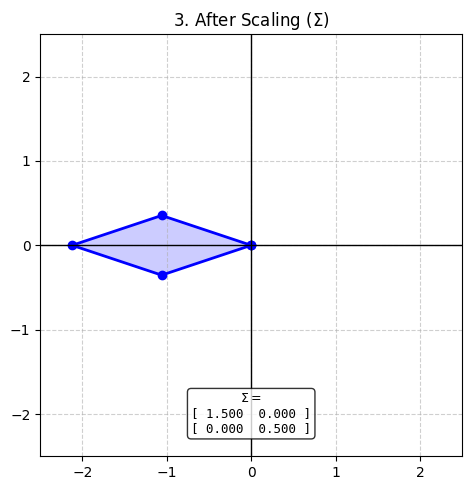

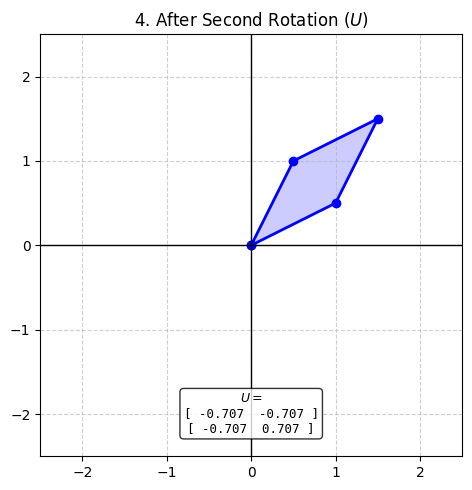

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the matrix A
A = np.array([[0.5, 1.0], [1.0, 0.5]])

# Compute SVD: A = U * Sigma * Vt
U, s, Vt = np.linalg.svd(A)
Sigma = np.diag(s)

# Create unit square points (closed loop)
unit_square = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
])

# Sequential transformations
step1_rotation = Vt @ unit_square
step2_scaling = Sigma @ step1_rotation
step3_final = U @ step2_scaling

# Plotting
titles = [
    "1. Unit Square",
    r"2. After First Rotation ($V^\top$)",
    r"3. After Scaling ($\Sigma$)",
    r"4. After Second Rotation ($U$)"
]
data = [unit_square, step1_rotation, step2_scaling, step3_final]

# Matrices and their labels
matrices = [None, Vt, Sigma, U]
matrix_labels = [None, r"V^\top", r"\Sigma", "U"]

limit = 2.5

def format_matrix_text(label, mat):
    """Formats a matrix as a string with brackets for display in plt.text."""
    rounded = np.round(mat, 3)
    # Create a string with the label and the matrix values inside brackets
    # Using a monospaced-style alignment
    res = f"${label} =$"
    res += f"\n[ {rounded[0,0]:.3f}  {rounded[0,1]:.3f} ]"
    res += f"\n[ {rounded[1,0]:.3f}  {rounded[1,1]:.3f} ]"
    return res

for i in range(4):
    figure = plt.figure(figsize=(5, 5))
    ax = figure.add_subplot(111)
    ax.plot(data[i][0, :], data[i][1, :], 'b-o', linewidth=2)
    ax.fill(data[i][0, :], data[i][1, :], alpha=0.2, color='blue')
    ax.set_title(titles[i])

    if matrices[i] is not None:
        matrix_str = format_matrix_text(matrix_labels[i], matrices[i])
        ax.text(0.5, 0.05, matrix_str, transform=ax.transAxes,
                fontsize=9, verticalalignment='bottom', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontfamily='monospace')

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)

    figure.tight_layout()
    figure.show()
